定义 state

---

- TypedDict: 属于 typing 模块的一部分，仅提供静态类型检查，运行时不执行验证
- Pydantic: 第三方库，提供运行时数据验证和序列化功能

In [ ]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

# 定义节点间通讯的消息格式
class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

定义节点

---

In [ ]:
from langchain_core.messages import AIMessage

def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("Hello, here's node_0")

    return {
        "messages": messages + [new_message],
        "extra_field": 0
    }

创建图

---

- 包含一个节点
- 使用 State 通信

In [ ]:
from langgraph.graph import StateGraph

graph = StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder = graph.compile()

查看节点与图结构

---

Mermaid 是基于文本的图标和可视化工具，允许通过简单的文本语法来创建复杂的图表和流程图

In [ ]:
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

调用

In [ ]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages": [HumanMessage("Hello, I'm a human")],
})

print(result)

使用 pretty_print 格式化显示输出

In [ ]:
for message in result["messages"]:
    message.pretty_print()

串行控制

---

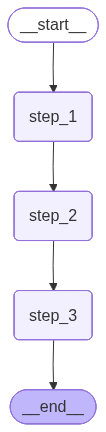

In [5]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import START, StateGraph, END

class State(TypedDict):
    value_1: str
    value_2: str

def step_1(state: State):
    return {"value_1": "a",}

def step_2(state: State):
    current_value_1 = state["value_1"]
    return {"value_1": f"{current_value_1} + b",}

def step_3(state: State):
    return {"value_2": 10}

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START, "step_1")
graph_builder.add_edge("step_1", "step_2")
graph_builder.add_edge("step_2", "step_3")
graph_builder.add_edge("step_3", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
graph.invoke({"value_1": "c"})

{'value_1': 'a + b', 'value_2': 10}

分支控制

---

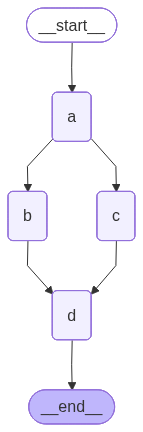

添加 a 到 []
添加 b 到 ['a']
添加 c 到 ['a']
添加 d 到 ['a', 'b', 'c']


{'aggregate': ['a', 'b', 'c', 'd']}

In [7]:
import operator
from typing import Any, Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    # Annotated 允许为类型提供额外的元数据而不影响类型检查对类型本身的理解
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加 a 到 {state['aggregate']}")
    return {"aggregate": ["a"]}

def b(state: State):
    print(f"添加 b 到 {state['aggregate']}")
    return {"aggregate": ["b"]}

def c(state: State):
    print(f"添加 c 到 {state['aggregate']}")
    return {"aggregate": ["c"]}

def d(state: State):
    print(f"添加 d 到 {state['aggregate']}")
    return {"aggregate": ["d"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

graph_builder.add_edge(START, "a")
graph_builder.add_edge("a", "b")
graph_builder.add_edge("a", "c")
graph_builder.add_edge("b", "d")
graph_builder.add_edge("c", "d")
graph_builder.add_edge("d", END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"aggregate": []}, {"configurable": {"thread_id": "foo"}})

条件分支

---

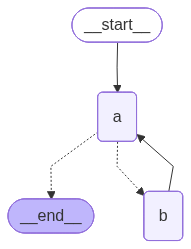

添加 a 看到 []
添加 b 看到 ['a']
添加 a 看到 ['a', 'b']
添加 b 看到 ['a', 'b', 'a']
添加 a 看到 ['a', 'b', 'a', 'b']
添加 b 看到 ['a', 'b', 'a', 'b', 'a']
添加 a 看到 ['a', 'b', 'a', 'b', 'a', 'b']


{'aggregate': ['a', 'b', 'a', 'b', 'a', 'b', 'a']}

In [ ]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加 a 看到 {state['aggregate']}")
    return {"aggregate": ["a"]}

def b(state: State):
    print(f"添加 b 看到 {state['aggregate']}")
    return {"aggregate": ["b"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)

def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "a")
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"aggregate": []})

循环

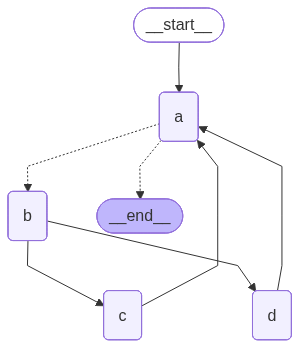

添加 a 看到 []
添加 b 看到 ['a']
添加 c 看到 ['a', 'b']
添加 d 看到 ['a', 'b']
添加 a 看到 ['a', 'b', 'c', 'd']
添加 b 看到 ['a', 'b', 'c', 'd', 'a']
添加 c 看到 ['a', 'b', 'c', 'd', 'a', 'b']
添加 d 看到 ['a', 'b', 'c', 'd', 'a', 'b']
添加 a 看到 ['a', 'b', 'c', 'd', 'a', 'b', 'c', 'd']


{'aggregate': ['a', 'b', 'c', 'd', 'a', 'b', 'c', 'd', 'a']}

In [6]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加 a 看到 {state['aggregate']}")
    return {"aggregate": ["a"]}

def b(state: State):
    print(f"添加 b 看到 {state['aggregate']}")
    return {"aggregate": ["b"]}

def c(state: State):
    print(f"添加 c 看到 {state['aggregate']}")
    return {"aggregate": ["c"]}

def d(state: State):
    print(f"添加 d 看到 {state['aggregate']}")
    return {"aggregate": ["d"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "c")
graph_builder.add_edge("b", "d")
graph_builder.add_edge(["c", "d"], "a")
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"aggregate": []})